In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MeanShift, SpectralClustering
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import minimum_spanning_tree
from sklearn.datasets import make_moons # make_blobs is also useful
import pandas as pd
import matplotlib
import sklearn
from sklearn import metrics
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict
from sklearn.model_selection import KFold
from sklearn import linear_model #New!
from sklearn.linear_model import HuberRegressor
import time
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, cross_val_predict, KFold, StratifiedKFold
from astroML.linear_model import LinearRegression, PolynomialRegression, BasisFunctionRegression, NadarayaWatson
import sklearn.gaussian_process as gp
from sklearn.pipeline import make_pipeline #This allows one to build different steps together
from sklearn.model_selection import GridSearchCV # New! This will be used to explore different hyperparameter choices.
from sklearn.gaussian_process.kernels import RBF
from sklearn.model_selection import LearningCurveDisplay, ShuffleSplit
from sklearn import mixture

In [26]:
data = pd.read_csv("clusterdata.csv", sep=r'\s+', header=None, names=['x', 'y'])

data

,x,y
0,-2.251697,1.598127
1,-2.450311,0.128423
2,-1.800657,1.967820
3,-1.536790,0.456200
4,-1.089249,-1.219327
...,...,...
895,2.121792,-3.083339
896,2.000644,-6.774344
897,1.888803,-5.172421
898,2.036690,-1.919785


In [27]:
# Create and fit K-means model
clf = KMeans(n_clusters=3, n_init = 10, random_state=30) #predicts 0,1,2
clf.fit(data)

X = data[['x', 'y']]

# Get cluster centers (centroids)
centers = clf.cluster_centers_
print(centers)  # These will be 3 points (each with x,y coordinates)

# Get labels for each point
labels = clf.predict(X)  # Each point gets label 0, 1, or 2

[[ 1.17419859  3.74321423]
 [ 1.55220853 -4.66456706]
 [ 0.2187765  -0.78091413]]


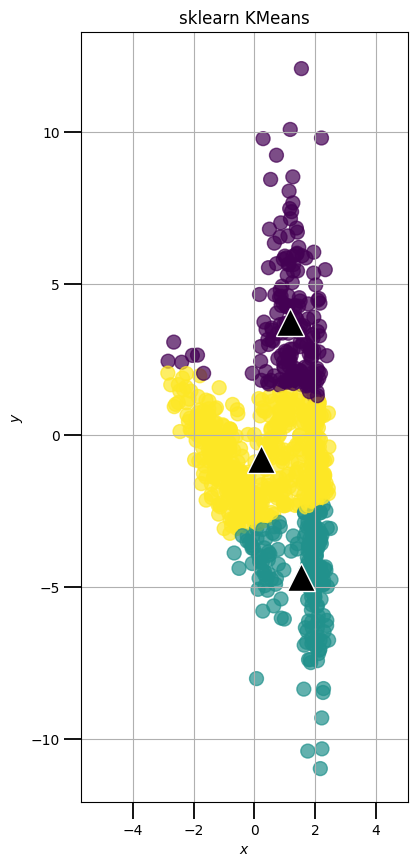

In [28]:
fig3 = plt.figure(figsize=(10,10))
plt.axes().set_aspect('equal')
plt.scatter(data['x'], data['y'], s=100, c=labels, alpha=0.7, cmap='viridis')
plt.plot(centers[:,0], centers[:,1], '^k', mec='white', ms=20)
plt.tick_params('both', length=12, width=1.3, which='major')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.grid('on')
plt.xlim(min(data['x'])*2,max(data['x']*2))
plt.ylim(min(data['y']*1.1), max(data['y']*1.1))
plt.title('sklearn KMeans')
plt.show()

In [29]:
spec = SpectralClustering(n_clusters=3, affinity='nearest_neighbors', assign_labels='kmeans')
labels_predict2 = spec.fit_predict(X)

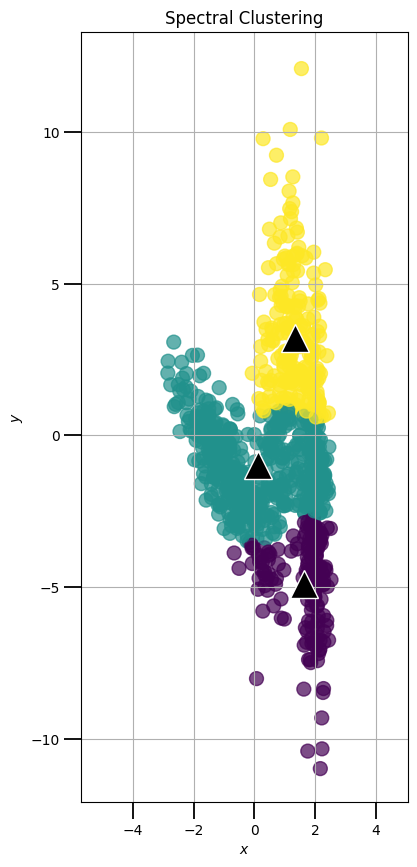

In [30]:
centers = []
for i in range(3):
    cluster_points = X[labels_predict2 == i]
    centers.append([cluster_points['x'].mean(), cluster_points['y'].mean()])
centers = np.array(centers)

# Create plot in the same format
fig3 = plt.figure(figsize=(10,10))
plt.axes().set_aspect('equal')
plt.scatter(data['x'], data['y'], s=100, c=labels_predict2, alpha=0.7, cmap='viridis')
plt.plot(centers[:,0], centers[:,1], '^k', mec='white', ms=20)
plt.tick_params('both', length=12, width=1.3, which='major')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.grid('on')
plt.xlim(min(data['x'])*2,max(data['x']*2))
plt.ylim(min(data['y']*1.1), max(data['y']*1.1))
plt.title('Spectral Clustering')
plt.show()


In [31]:
gauss = mixture.GaussianMixture(n_components=3, covariance_type='full',random_state=41)
gauss.fit(X)


,"n_components n_components: int, default=1The number of mixture components.",3
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",41


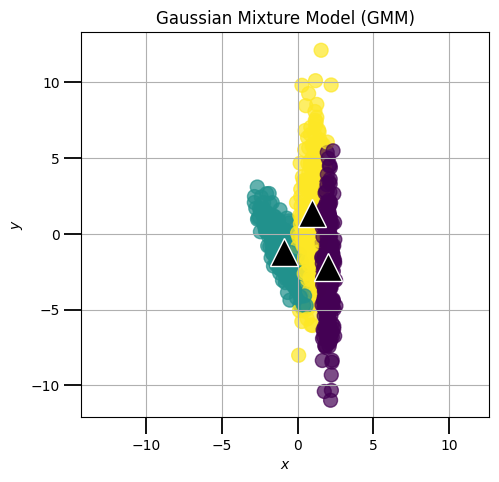

In [35]:
# Get results
centers = gauss.means_  # Cluster centers (means)
labels = gauss.predict(X)  # Cluster assignments
probs = gauss.predict_proba(X)  # Probabilities of belonging to each cluster

# Create plot in the same format as before
fig13 = plt.figure(figsize=(10,5))
plt.axes().set_aspect('equal')
plt.scatter(data['x'], data['y'], s=100, c=labels, alpha=0.7, cmap='viridis')
plt.plot(centers[:,0], centers[:,1], '^k', mec='white', ms=20)
plt.tick_params('both', length=12, width=1.3, which='major')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.grid('on')
plt.xlim(min(data['x'])*5,max(data['x']*5))
plt.ylim(min(data['y']*1.1), max(data['y']*1.1))
plt.title('Gaussian Mixture Model (GMM)')
plt.show()